# Ecuación de onda en 2D con algoritmo Leapfrog

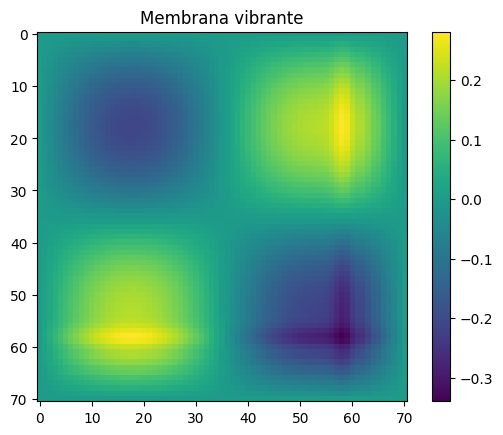

In [2]:
import numpy as np
import matplotlib.pyplot as plt

N = 71
dx = 1.0/N
dt = 0.001
c = 1.0

r = (c*dt/dx)**2

u = np.zeros((N, N))
u_prev = np.zeros((N, N))
u_next = np.zeros((N, N))

for i in range(N):
    for j in range(N):
        x = i*dx
        y = j*dx
        u[i,j] = np.sin(2*np.pi*x)*np.sin(2*np.pi*y)

u_prev = np.copy(u)

for step in range(200):
    for i in range(1, N-1):
        for j in range(1, N-1):
            u_next[i,j] = 2*u[i,j] - u_prev[i,j] + r*(u[i+1,j] + u[i-1,j] + u[i,j+1] + u[i,j-1] - 4*u[i,j])
    
    u_prev = np.copy(u)
    u = np.copy(u_next)

X, Y = np.meshgrid(range(N), range(N))
plt.imshow(u, cmap='viridis')
plt.colorbar()
plt.title('Membrana vibrante')
plt.show()

# Ecuación de Transporte Advectivo

Describe el movimiento de una cantidad que se transporta a través de un medio con una velocidad constante. La ecuación es:

$\frac{\partial u}{\partial t} + c \frac{\partial u}{\partial x} = 0$

- $u(x,t)$ : densidad o cantidad transportada
- $c$ : velocidad de transporte

La ecuación discretizada con el método de diferencias finitas es:

$\frac{u_i^{n+1} - u_i^{n-1}}{\Delta t} + c \frac{u_{i+1}^n - u_{i-1}^n}{\Delta x} = 0$ y si despejamos $u_i^{n+1}$ obtenemos:

$u_i^{n+1} = u_i^{n-1} - \frac{c \Delta t}{\Delta x} (u_{i+1}^n - u_{i-1}^n)$

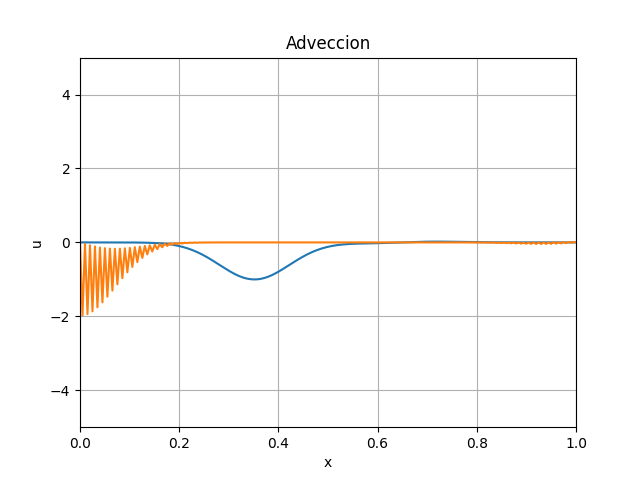

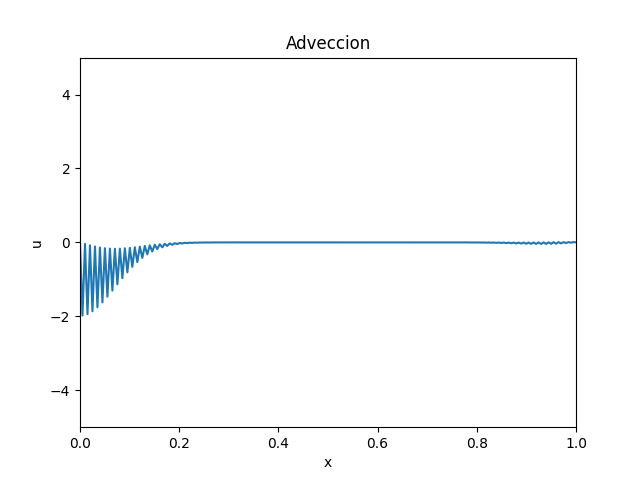

In [11]:
from matplotlib.animation import FuncAnimation

N = 200
L = 1.0
dx = L/N
dt = 0.005
c = 1.0

u = np.zeros(N)
u_old = np.zeros(N)
u_new = np.zeros(N)

x = np.linspace(0, L, N)

# Pulso gaussiano
u = np.exp(-100*(x-0.5)**2)

u_old = np.copy(u)

for step in range(300):
    for i in range(1, N-1):
        u_new[i] = u_old[i] - (c*dt/dx)*(u[i+1] - u[i-1])
    
    u_old = np.copy(u)
    u = np.copy(u_new)

plt.plot(x, u)
plt.title('Adveccion')
plt.xlabel('x')
plt.ylabel('u')
plt.grid()
plt.show()

# Animación en 2D

fig, ax = plt.subplots()
line, = ax.plot(x, u)
ax.set_xlim(0, L)
ax.set_ylim(-5.0, 5.0)
ax.set_xlabel('x')
ax.set_ylabel('u')
ax.set_title('Adveccion')

def update(frame):
    global u, u_old, u_new
    for i in range(1, N-1):
        u_new[i] = u_old[i] - (c*dt/dx)*(u[i+1] - u[i-1])
    u_old = np.copy(u)
    u = np.copy(u_new)
    line.set_ydata(u)
    return line,

ani = FuncAnimation(fig, update, frames=300, blit=True)
plt.show()

# Korteweg-De Vries (KdV)

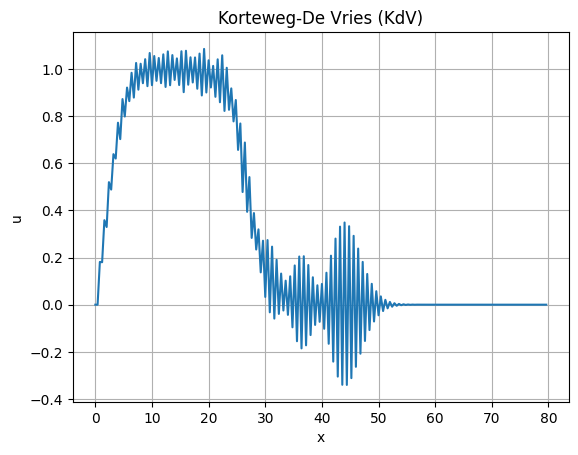

In [3]:
N = 200
dx = 0.4
dt = 0.1
eps = 0.2
mu = 0.1

u = np.zeros(N)
u_old = np.zeros(N)
u_new = np.zeros(N)

x = np.arange(N)*dx

u = 0.5*(1 - np.tanh(x/5 - 5))
u_old = np.copy(u)

for n in range(200):
    for i in range(2, N-2):
        nonlinear = (u[i+1] + u[i] + u[i-1])*(u[i+1] - u[i-1])
        dispersion = (u[i+2] + 2*u[i-1] - 2*u[i+1] - u[i-2])

        u_new[i] = u_old[i] - eps*dt/(3*dx)*nonlinear - mu*dt/(dx**3)*dispersion

    u_old = np.copy(u)
    u = np.copy(u_new)

plt.plot(x, u)
plt.title('Korteweg-De Vries (KdV)')
plt.xlabel('x')
plt.ylabel('u')
plt.grid()
plt.show()